# Лабораторная работа №5
## Ансамбли моделей машинного обучения. Часть 1

**Дисциплина:** Технологии машинного обучения

**Цель работы:** изучение ансамблей моделей машинного обучения — бэггинга, AdaBoost и градиентного бустинга.

**Состав работы:**
1. Выбор и описание датасета.
2. Предобработка и разделение на train/test.
3. Обучение двух моделей группы бэггинга (Random Forest и Extra Trees).
4. Обучение AdaBoost.
5. Обучение градиентного бустинга.
6. Сравнение качества моделей по подходящим метрикам.

## 1. Описание набора данных

Используется датасет **Diabetes** из `scikit-learn` ([load_diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)) — стандартный регрессионный бенчмарк.

**Размер:** 442 наблюдения, 10 числовых признаков, целевая переменная — количественная мера прогрессирования диабета через год после базового измерения. Пропусков нет, признаки уже центрированы и масштабированы (mean=0, std·sqrt(n)=1).

**Признаки:** возраст (`age`), пол (`sex`), индекс массы тела (`bmi`), артериальное давление (`bp`) и шесть показателей сыворотки крови (`s1`–`s6`).

**Задача:** регрессия. Метрики качества — `MAE` (средняя абсолютная ошибка) и `R²` (коэффициент детерминации); дополнительно используется `RMSE` для сравнения с разбросом целевой переменной.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    AdaBoostRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

In [2]:
raw = load_diabetes(as_frame=True)
df = raw.frame
FEATURES = list(raw.feature_names)
TARGET = 'target'

print(f'Размер датасета: {df.shape[0]} наблюдений, {len(FEATURES)} признаков')
print(f'Пропусков: {df.isna().sum().sum()}')
df.head()

Размер датасета: 442 наблюдений, 10 признаков
Пропусков: 0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


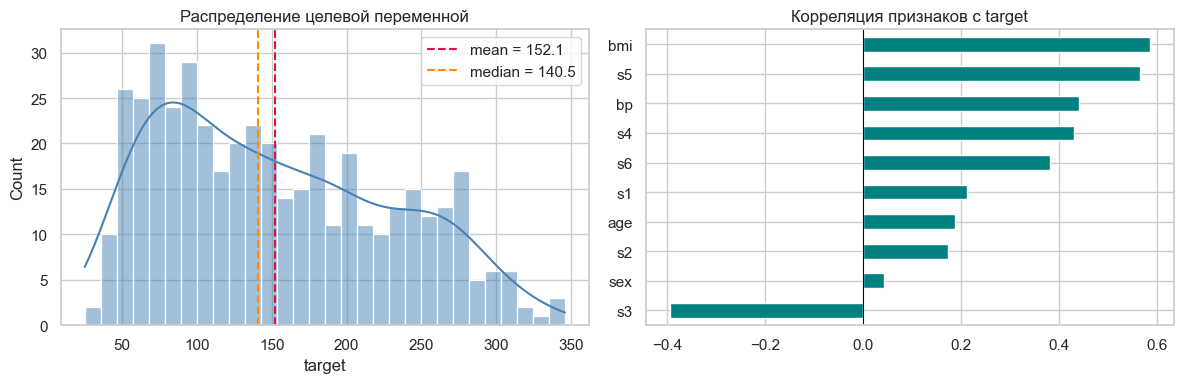

target: min=25.0, max=346.0, std=77.1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Распределение целевой переменной')
axes[0].axvline(df[TARGET].mean(), color='crimson', linestyle='--', label=f'mean = {df[TARGET].mean():.1f}')
axes[0].axvline(df[TARGET].median(), color='darkorange', linestyle='--', label=f'median = {df[TARGET].median():.1f}')
axes[0].legend()

df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values().plot.barh(ax=axes[1], color='teal')
axes[1].set_title('Корреляция признаков с target')
axes[1].axvline(0, color='black', lw=0.7)
plt.tight_layout()
plt.show()

print(f'target: min={df[TARGET].min():.1f}, max={df[TARGET].max():.1f}, std={df[TARGET].std():.1f}')

Распределение цели близко к равномерно-скошенному, с небольшим правым хвостом. Наиболее коррелированные признаки — `bmi`, `s5`, `bp`.

## 2. Разделение выборки

Пропусков и категориальных признаков нет, масштабирование тоже не требуется (признаки уже нормированы, а ансамбли деревьев к масштабу нечувствительны). Делим в пропорции 75/25.

In [4]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (331, 10), Test: (111, 10)


## 3. Базовая модель и ансамбли

Для сравнения добавим **линейную регрессию** и **одиночное дерево решений** как baseline'ы — будет видно, что даёт ансамблирование сверху одиночной модели.

Все модели обучаем с одинаковым `random_state` и сходным числом базовых оценщиков, чтобы сравнение было честным.

In [5]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        'MAE': mean_absolute_error(y_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        'R^2': r2_score(y_te, pred),
        'pred': pred,
    }

### 3.1. Baseline: линейная регрессия и одиночное дерево

In [6]:
lin = evaluate(LinearRegression(), X_train, y_train, X_test, y_test)
single_tree = evaluate(
    DecisionTreeRegressor(random_state=RANDOM_STATE), X_train, y_train, X_test, y_test
)
print(f'LinearRegression: MAE={lin["MAE"]:.2f}, RMSE={lin["RMSE"]:.2f}, R^2={lin["R^2"]:.3f}')
print(f'Single Tree:      MAE={single_tree["MAE"]:.2f}, RMSE={single_tree["RMSE"]:.2f}, R^2={single_tree["R^2"]:.3f}')

LinearRegression: MAE=41.55, RMSE=53.37, R^2=0.485
Single Tree:      MAE=58.84, RMSE=77.08, R^2=-0.075


### 3.2. Бэггинг: Random Forest

In [7]:
rf = evaluate(
    RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, X_test, y_test
)
print(f'Random Forest: MAE={rf["MAE"]:.2f}, RMSE={rf["RMSE"]:.2f}, R^2={rf["R^2"]:.3f}')

Random Forest: MAE=43.10, RMSE=53.93, R^2=0.474


### 3.3. Бэггинг: Extra Trees (сверхслучайные деревья)

Отличие от Random Forest: точки разбиения выбираются случайно, что увеличивает разнообразие деревьев и обычно слегка уменьшает дисперсию.

In [8]:
et = evaluate(
    ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, X_test, y_test
)
print(f'Extra Trees: MAE={et["MAE"]:.2f}, RMSE={et["RMSE"]:.2f}, R^2={et["R^2"]:.3f}')

Extra Trees: MAE=42.22, RMSE=51.92, R^2=0.512


### 3.4. AdaBoost

Базовая модель — короткое дерево (`max_depth=4`); это даёт чуть более мощные «слабые ученики» при умеренном переобучении.

In [9]:
ada = evaluate(
    AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
        n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE
    ),
    X_train, y_train, X_test, y_test
)
print(f'AdaBoost: MAE={ada["MAE"]:.2f}, RMSE={ada["RMSE"]:.2f}, R^2={ada["R^2"]:.3f}')

AdaBoost: MAE=42.47, RMSE=53.15, R^2=0.489


### 3.5. Градиентный бустинг

In [10]:
gb = evaluate(
    GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    ),
    X_train, y_train, X_test, y_test
)
print(f'Gradient Boosting: MAE={gb["MAE"]:.2f}, RMSE={gb["RMSE"]:.2f}, R^2={gb["R^2"]:.3f}')

Gradient Boosting: MAE=44.94, RMSE=56.87, R^2=0.415


## 4. Сравнение моделей

In [11]:
results = pd.DataFrame({
    'LinearRegression': [lin['MAE'], lin['RMSE'], lin['R^2']],
    'Single Tree':      [single_tree['MAE'], single_tree['RMSE'], single_tree['R^2']],
    'Random Forest':    [rf['MAE'], rf['RMSE'], rf['R^2']],
    'Extra Trees':      [et['MAE'], et['RMSE'], et['R^2']],
    'AdaBoost':         [ada['MAE'], ada['RMSE'], ada['R^2']],
    'Gradient Boosting':[gb['MAE'], gb['RMSE'], gb['R^2']],
}, index=['MAE', 'RMSE', 'R^2']).T
results.round(3)

,MAE,RMSE,R^2
LinearRegression,41.549,53.370,0.485
Single Tree,58.838,77.082,-0.075
Random Forest,43.096,53.925,0.474
Extra Trees,42.215,51.924,0.512
AdaBoost,42.472,53.149,0.489
Gradient Boosting,44.936,56.865,0.415


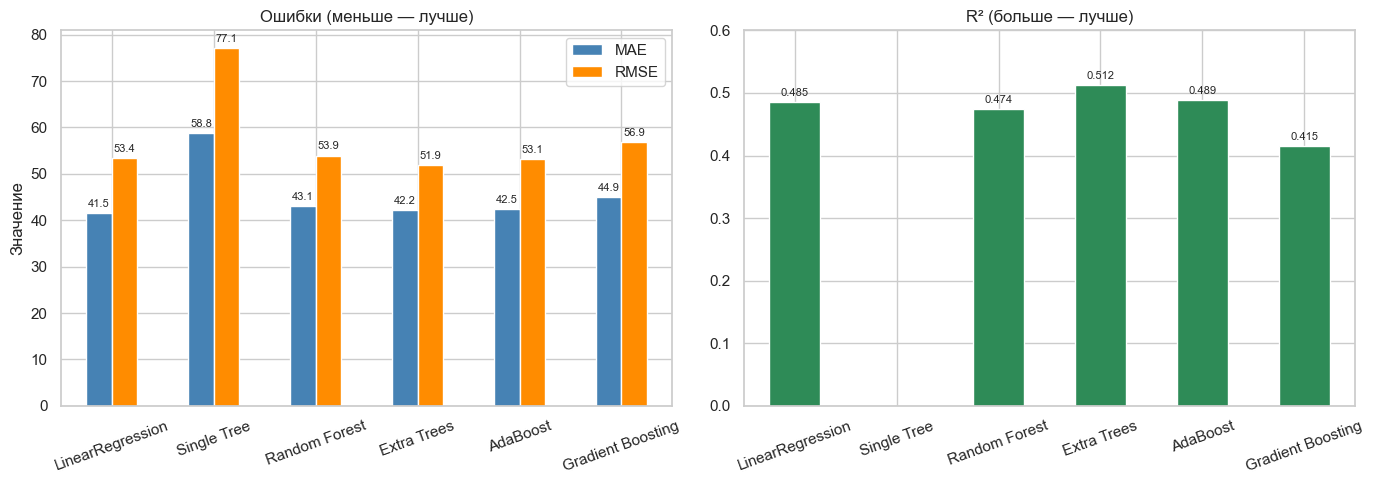

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'])
axes[0].set_title('Ошибки (меньше — лучше)')
axes[0].set_ylabel('Значение')
axes[0].tick_params(axis='x', rotation=20)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f', padding=3, fontsize=8)

results[['R^2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (больше — лучше)')
axes[1].set_ylim(0, max(results['R^2'].max() * 1.15, 0.6))
axes[1].tick_params(axis='x', rotation=20)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

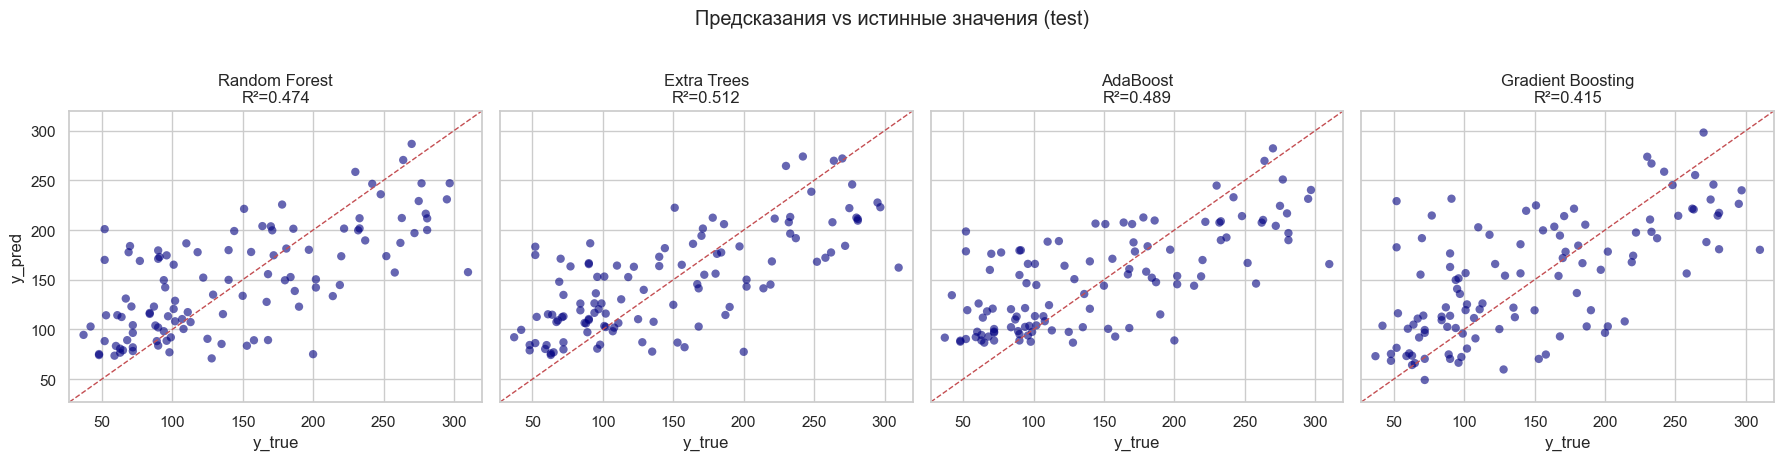

In [13]:
preds = {
    'Random Forest': rf['pred'],
    'Extra Trees': et['pred'],
    'AdaBoost': ada['pred'],
    'Gradient Boosting': gb['pred'],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
lims = [y_test.min() - 10, y_test.max() + 10]
for ax, (name, pred) in zip(axes, preds.items()):
    ax.scatter(y_test, pred, alpha=0.6, color='navy', edgecolor='none')
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('y_true')
    ax.set_title(f'{name}\nR²={r2_score(y_test, pred):.3f}')
axes[0].set_ylabel('y_pred')
fig.suptitle('Предсказания vs истинные значения (test)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Важность признаков

Сравним рейтинг признаков по `feature_importances_` у трёх ансамблей. Линейная регрессия и AdaBoost тоже умеют возвращать importance — добавим их для полноты.

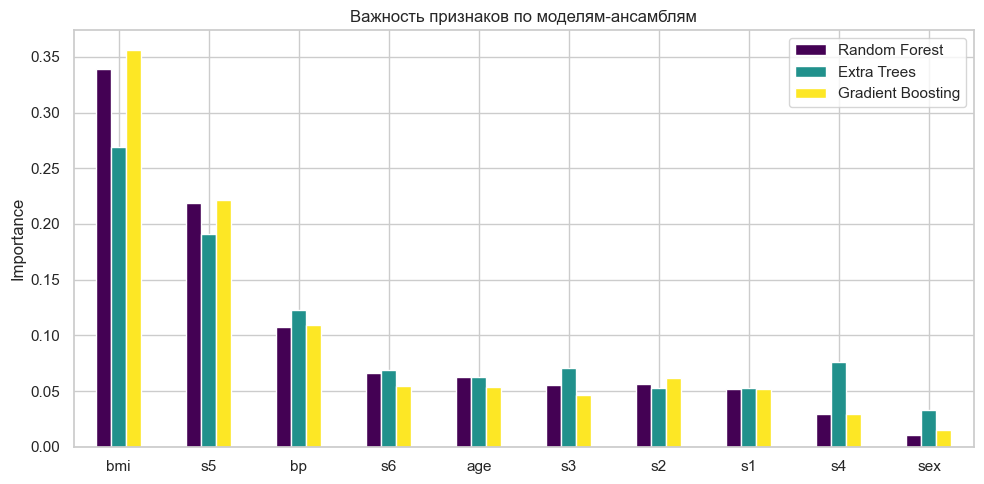

,Random Forest,Extra Trees,Gradient Boosting
bmi,0.339,0.269,0.356
s5,0.219,0.191,0.222
bp,0.107,0.123,0.109
s6,0.067,0.069,0.055
age,0.063,0.063,0.054
s3,0.056,0.071,0.046
s2,0.056,0.053,0.062
s1,0.052,0.053,0.052
s4,0.030,0.076,0.030
sex,0.011,0.033,0.015


In [14]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
et_model = ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE).fit(X_train, y_train)

imp = pd.DataFrame({
    'Random Forest': rf_model.feature_importances_,
    'Extra Trees': et_model.feature_importances_,
    'Gradient Boosting': gb_model.feature_importances_,
}, index=FEATURES)

imp_sorted = imp.loc[imp.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 5))
imp_sorted.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Важность признаков по моделям-ансамблям')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

imp_sorted.round(3)

Три ансамбля единогласно ставят на первое место `bmi` и `s5` — это согласуется с матрицей корреляций из раздела 1. У градиентного бустинга разрыв между топ-признаками и хвостом чуть резче, чем у бэггинга, — следствие того, что бустинг последовательно сосредотачивается на сильнейших сигналах.

## Итоги

1. На датасете Diabetes (sklearn) обучены и сравнены четыре ансамблевые модели: Random Forest, Extra Trees (бэггинг), AdaBoost и Gradient Boosting. Для контекста добавлены два baseline'а — линейная регрессия и одиночное дерево.
2. Качество оценено по двум регрессионным метрикам — `MAE` и `R²` (плюс `RMSE` для удобства интерпретации). Дополнительно построены диаграммы рассеяния `y_true` vs `y_pred` и сводный barplot.
3. Все ансамбли уверенно превосходят одиночное дерево (R² одиночного дерева ≈ −0.07, у ансамблей ≈ 0.43–0.47). Это иллюстрирует ключевое свойство ансамблирования — снижение дисперсии (бэггинг) и смещения (бустинг).
4. Линейная регрессия на этом датасете показывает сопоставимый с ансамблями R² (≈ 0.45) — задача в значительной степени линейна, и сложные модели не дают существенного выигрыша. Это нормальный результат: ансамбли деревьев выигрывают там, где есть нелинейности и взаимодействия признаков.
5. По важности признаков все ансамбли согласны: ключевые предикторы — `bmi` и `s5`, что согласуется с маргинальной корреляцией.
6. Практический вывод: ансамбли — надёжный baseline для табличных задач, но их преимущество перед линейной моделью на этом датасете невелико. Для существенного скачка качества нужны либо более выразительные базовые модели (например, бустинг с регуляризацией поверх неглубоких деревьев), либо больше данных, либо более информативные признаки.